In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift

In [ ]:
def butterworth_lowpass(shape, D, n):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2 
    
    u = np.arange(rows) - crow
    v = np.arange(cols) - ccol
    U, V = np.meshgrid(v, u)
    D_uv = np.sqrt(U**2 + V**2)
    
    # Формула ФНЧ Баттерворта
    H = 1 / (1 + (D_uv / D)**(2*n))
    return H

def butterworth_highpass(shape, D, n):
    lowpass = butterworth_lowpass(shape, D, n)
    return 1 - lowpass

def apply_frequency_filter(image, mask):
    F = fft2(image)
    F_shifted = fftshift(F)
    
    F_filtered = F_shifted * mask
    
    F_ishifted = ifftshift(F_filtered)
    img_back = ifft2(F_ishifted)
    img_back = np.abs(img_back)
    
    img_back = (img_back - img_back.min()) / (img_back.max() - img_back.min())
    return img_back

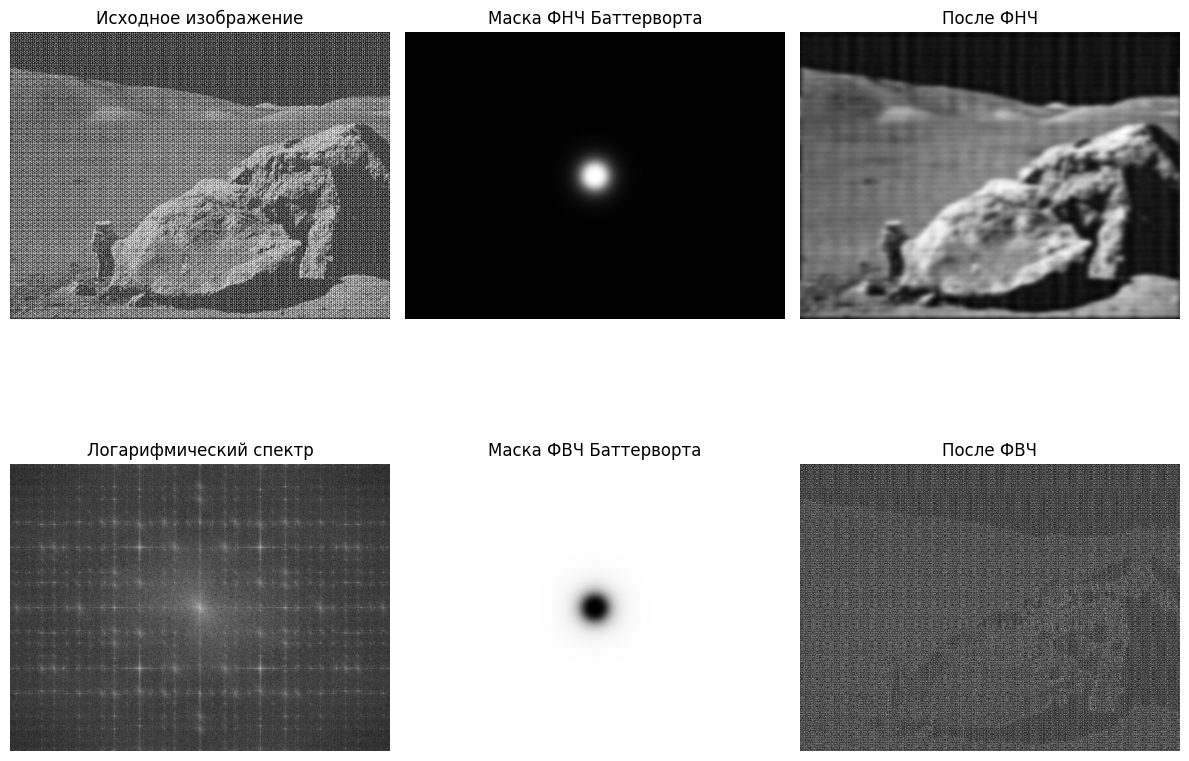

In [ ]:
if __name__ == "__main__":
    img = cv2.imread('periodic_noise.jpg', cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError("ошибка загрузки изображения")

    img_float = img.astype(np.float32) / 255.0
    
    rows, cols = img.shape
    
    D = 30          # частота среза (радиус в пикселях)
    n = 2           # порядок фильтра
    
    lowpass_mask = butterworth_lowpass((rows, cols), D, n)
    highpass_mask = butterworth_highpass((rows, cols), D, n)
    
    img_lowpass = apply_frequency_filter(img_float, lowpass_mask)
    img_highpass = apply_frequency_filter(img_float, highpass_mask)
    
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 3, 1)
    plt.imshow(img_float, cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.imshow(lowpass_mask, cmap='gray')
    plt.title('Маска ФНЧ Баттерворта')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.imshow(img_lowpass, cmap='gray')
    plt.title('После ФНЧ')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(highpass_mask, cmap='gray')
    plt.title('Маска ФВЧ Баттерворта')
    plt.axis('off')
    
    plt.subplot(2, 3, 6)
    plt.imshow(img_highpass, cmap='gray')
    plt.title('После ФВЧ')
    plt.axis('off')
    
    # спектр исходного изображения
    F_orig = fftshift(fft2(img_float))
    magnitude_spectrum = np.log(1 + np.abs(F_orig))
    
    plt.subplot(2, 3, 4)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Логарифмический спектр')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()